In [12]:
%load_ext autoreload
%autoreload 2

In [13]:
import sys
import os
sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal
from sklearn.linear_model import LinearRegression
from Scripts import Outlier_detection_v2
from Scripts import Genes_self_similarity_v2
from matplotlib_venn import venn2, venn2_circles
from tqdm import tqdm
from Scripts_Imane import Format_Data

import torch

In [20]:
#data = pd.read_csv("Data/database_phase_1_after_preprocessing_with_right_WT_07_23_2024.csv") #! only one with 40 and 80 exact, 1_24+99 plates, messy creepy graphs
#data = pd.read_parquet("Data/database_2024-08-03.parquet") # +'30v1' '30v2' '30v3' '98v1' '98v2' '98v3', same thing as the one below ig neat, has std
#data = pd.read_parquet("Data/20240721_database.parquet") #+'30v1' '30v2' '30v3', 8 regimes, neat graphs, no std
#data = pd.read_csv('Data/database_phase_1_after_preprocessing_with_right_WT_07_23_2024.csv')  #only plates 1-24+99, 6 regimes, messy y2 graphs
#data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-04-25.csv')
#data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-04-30.csv')

#data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-05-02.csv')
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-05-18.csv')

''''30v1' '30v2' '30v3' '98v1' '98v2' '98v3' '31v1' '32v1' '31v2' '32v2' '31v3''32v3' '33v1' '33v2' '33v3' '99' 
All the graphs with extra plates and neat graphs have a overlapping prob in the 2H_2H regime y2 plot
'''


/tmp/ipykernel_55410/19736093.py:9: DtypeWarning: Columns (0,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,723,724) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/database_2025-05-18.csv')


"'30v1' '30v2' '30v3' '98v1' '98v2' '98v3' '31v1' '32v1' '31v2' '32v2' '31v3''32v3' '33v1' '33v2' '33v3' '99' \nAll the graphs with extra plates and neat graphs have a overlapping prob in the 2H_2H regime y2 plot\n"

## Format and separate phase 1 and 2

In [25]:
new = Format_Data.get_format_data(new)

/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Scripts_Imane/Format_Data.py:131: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data.insert(insert_at + i, col, elapsed_hours.iloc[:, i])
/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Scripts_Imane/Format_Data.py:131: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data.insert(insert_at + i, col, elapsed_hours.iloc[:, i])
/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Scripts_Imane/Format_Data.py:131: PerformanceWarning: DataFrame is highly fragmented.  This i

In [21]:
old = data[(data['start_date'] < '2024-05-19')]   
transition = data[((data['plate'] == '20') | (data['plate'] == '99')) & (data['start_date'] >= '2024-05-19')]
new = data[(data['plate'].astype(str) != '20') & (data['start_date'] >= '2024-05-19')]
new['plate'] = new['plate'].astype(str)









/tmp/ipykernel_55410/3274879425.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new['plate'] = new['plate'].astype(str)


In [22]:
# DROP REPLICAS
new = Format_Data.remove_oldbad_plates(new)
# DROP REPLICAS
old = Format_Data.remove_oldbad_plates(old)

myea


/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Scripts_Imane/Format_Data.py:198: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['start_date'] = pd.to_datetime(data['start_date'])


myea


/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Scripts_Imane/Format_Data.py:198: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['start_date'] = pd.to_datetime(data['start_date'])


In [8]:
new[new['plate']==99]['light_regime'].unique()


array([], dtype=object)

In [ ]:
new[new['plate'].astype(str).str.startswith('99v3')]['light_regime'].unique()

array([99, '99', '20', '30v1', '30v2', '30v3', '98v1', '98v2', '98v3',
       '31v1', '32v1', '31v2', '32v2', '31v3', '32v3', '99v1', '33v1',
       '33v2', '33v3', '99v3'], dtype=object)

In [12]:
new['plate'].unique()

array(['99', '30v1', '30v2', '30v3', '98v1', '98v2', '98v3', '31v1',
       '32v1', '31v2', '32v2', '31v3', '32v3', '99v1', '33v1', '33v2',
       '33v3', '99v3'], dtype=object)

In [34]:
data['plate'].unique()


array(['30v1', '20', '17', '98v2', '99v1', '98v3', '1', '30v3', '98v1',
       '5', '3', '99', '21', '32v3', '30v2', '18', '33v2', '16', '10',
       '7', '6', '14', '32v2', '13', '99v3', '31v3', '2', '33v1', '8',
       '12', '23', 1, 17, 11, '11', '32v1', 23, 14, 5, '31v1', '4',
       '31v2', '24', '9', '22', 18, 24, 6, 16, 22, '33v3', 9, 4, '15', 99,
       15, 10, 7, 8, 13], dtype=object)

In [46]:
old[old['plate']=='9']

,plate,measurement,start_date,light_regime,dark_threshold,light_threshold,num_frames,i,j,fv_fm,...,measurement_time_173,measurement_time_174,measurement_time_175,measurement_time_176,measurement_time_177,well_id,mutant_ID,feature,mutated_genes,num_mutations


In [47]:
old.shape
#(107718, 726)  5 
# (113846, 726)

# old murray : (53332, 726)

(52949, 726)

In [11]:
data = new

In [15]:
lights = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']
for light in lights :
    print(data[(data['plate']==99) & (data['light_regime']==light)]['mutant_ID'].shape)

(0,)
(383,)
(383,)
(383,)
(0,)
(383,)
(383,)
(383,)


In [16]:
Format_Data.sanity_checks(data)

Earliest start date : 2024-05-19 00:00:00
Most recent start date : 2024-11-27 00:00:00
Light regimes : ['1min-1min' '20h_ML' '2h-2h' '30s-30s' '10min-10min' '1min-5min' '20h_HL'
 '5min-5min']
Number of unique plates : 20
Unique plates : [99 '20' '30v1' '30v2' '30v3' '98v1' '98v2' '98v3' '31v1' '32v1' '31v2'
 '32v2' '31v3' '32v3' '99v1' '33v1' '33v2' '33v3' '99v3' '99']
6 plates have 6 unique light regimes.
1 plates have 4 unique light regimes.
6 plates have 8 unique light regimes.
5 plates have 7 unique light regimes.
1 plates have 5 unique light regimes.
1 plates have 2 unique light regimes.


In [26]:
#old.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase1.csv')
new.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2.csv')

## Comparing 30/04 and 25/04

In [1]:
# Ensure same column order and types
import pandas as pd
df1=pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2.csv')
df2=pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_4_phase2.csv')
df1=df1[df1['plate'].str.startswith('31')]
df2=df2[df2['plate'].str.startswith('31')]
df1_sorted = df1.sort_index(axis=1)
df2_sorted = df2.sort_index(axis=1)


# Combine both, drop duplicates that are in both → keep only differing rows
diff = pd.concat([df1_sorted, df2_sorted]).drop_duplicates(keep=False)

print(diff)


/tmp/ipykernel_902089/2036590735.py:3: DtypeWarning: Columns (462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  df1=pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2.csv')
/tmp/ipykernel_902089/2036590735.py:4: DtypeWarning: Columns (462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  df2=pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_4_phase2.csv')


       Unnamed: 0  dark_threshold  elapsed_hours_0  elapsed_hours_1  \
17275       78579       15.812491              0.0         0.150000   
17276       78588       15.812491              0.0         0.150000   
17277       78587       15.812491              0.0         0.150000   
17278       78586       15.812491              0.0         0.150000   
17279       78581       15.812491              0.0         0.150000   
...           ...             ...              ...              ...   
51593      110689       16.274685              0.0         0.083333   
51594      110688       16.274685              0.0         0.083333   
51595      110687       16.274685              0.0         0.083333   
51596      110698       16.274685              0.0         0.083333   
51597      110986       16.274685              0.0         0.083333   

       elapsed_hours_10  elapsed_hours_11  elapsed_hours_12  elapsed_hours_13  \
17275            0.8375          0.988611          1.005556       

In [5]:
key_cols = ['mutant_ID', 'mutated_genes', 'well_id', 'plate','light_regime']  # adapt to your context

merged = pd.merge(
    df1[key_cols],
    df2[key_cols],
    how='outer',
    indicator=True
)

diff = merged[merged['_merge'] != 'both']
diff['mutant_ID'].unique()


array(['WT'], dtype=object)

/tmp/ipykernel_1670904/4219625273.py:5: DtypeWarning: Columns (593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,723) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_slopeWTsubtracted.csv')


['measurement_time_0', 'measurement_time_1', 'measurement_time_2', 'measurement_time_3', 'measurement_time_4', 'measurement_time_5', 'measurement_time_6', 'measurement_time_7', 'measurement_time_8', 'measurement_time_9', 'measurement_time_10', 'measurement_time_11', 'measurement_time_12', 'measurement_time_13', 'measurement_time_14', 'measurement_time_15', 'measurement_time_16', 'measurement_time_17', 'measurement_time_18', 'measurement_time_19', 'measurement_time_20', 'measurement_time_21', 'measurement_time_22', 'measurement_time_23', 'measurement_time_24', 'measurement_time_25', 'measurement_time_26', 'measurement_time_27', 'measurement_time_28', 'measurement_time_29', 'measurement_time_30', 'measurement_time_31', 'measurement_time_32', 'measurement_time_33', 'measurement_time_34', 'measurement_time_35', 'measurement_time_36', 'measurement_time_37', 'measurement_time_38', 'measurement_time_39', 'measurement_time_40', 'measurement_time_41', 'measurement_time_42', 'measurement_time_43

/tmp/ipykernel_1670904/4219625273.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize='small', loc='upper right')
/tmp/ipykernel_1670904/4219625273.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize='small', loc='upper right')
/tmp/ipykernel_1670904/4219625273.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize='small', loc='upper right')
/tmp/ipykernel_1670904/4219625273.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.lege

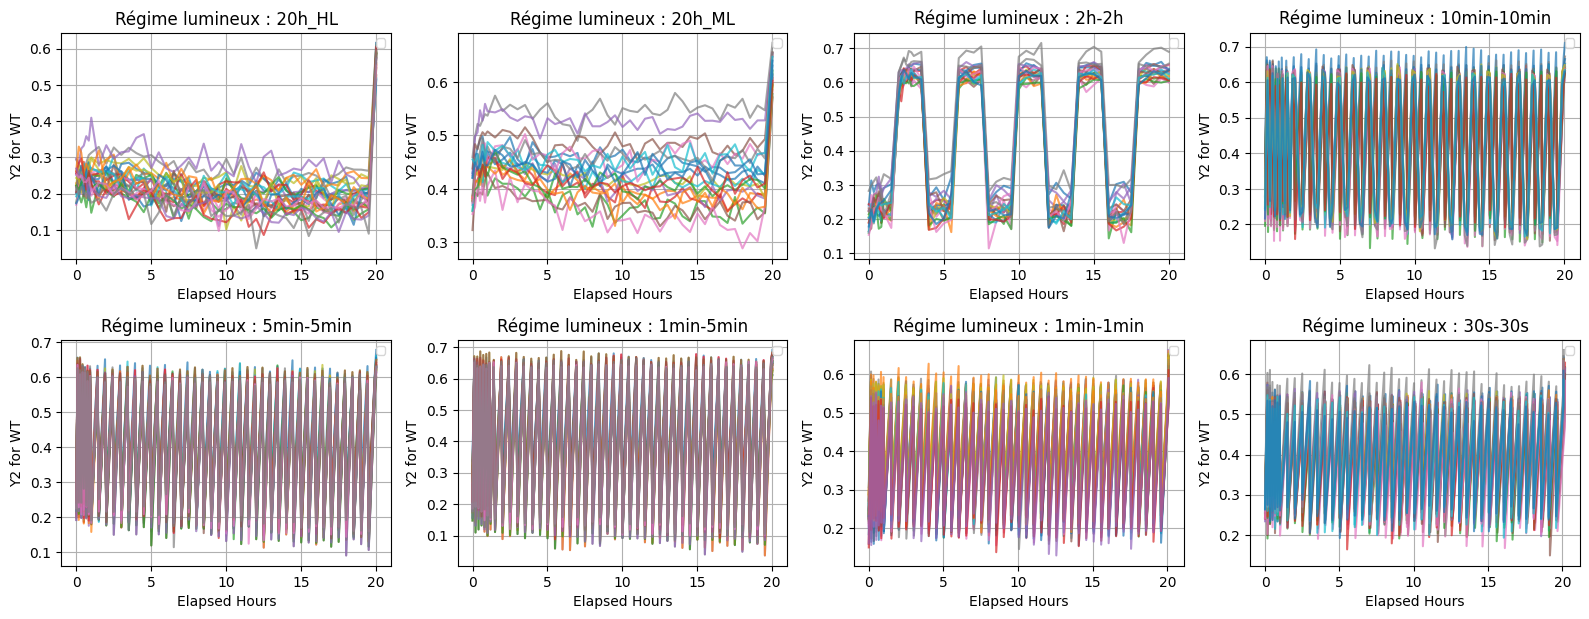

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/phase2_05_slopeWTsubtracted.csv')
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]
time_columns = [col for col in data.columns if col.startswith('measurement_time_')]
print(time_columns)

for col in time_columns:
    data[col] = pd.to_datetime(data[col],format='mixed')

elapsed_hours = data[time_columns].apply(lambda row: (row - row.min()).dt.total_seconds() / 3600, axis=1)

elapsed_hours.columns = [f'elapsed_hours_{i}' for i in range(len(elapsed_hours.columns))]
data = pd.concat([data, elapsed_hours], axis=1)

light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']

fig, axes = plt.subplots(4, 4, figsize=(16, 12))  # 4x4 grille
axes = axes.flatten()  # Aplatir la grille pour un accès facile

# Tracer les graphiques pour chaque régime lumineux
for i, light in enumerate(light_regimes):
    ax = axes[i]  # Sélectionner l'axe correspondant
    data_light = data[(data['light_regime'] == light) & (data['plate'].astype(str).str.startswith('30'))]  # Filtrer les données pour le régime lumineux actuel
    
    # Tracer les courbes pour chaque plaque
    for plate in data_light['plate'].unique():
        data_plate = data_light[(data_light['mutant_ID'].isin(['WT', 'WT CLiP'])) & (data_light['plate'] == plate)]
        
        for _, row in data_plate.iterrows():
            y2_values = row[y2_columns].values  # Extraire les valeurs y2
            time_values = row[elapsed_hours.columns].astype(float).values

            valid_indices = ~np.isnan(time_values)
            time_values = time_values[valid_indices]
            y2_values = y2_values[:len(time_values)]  # Assurez-vous que y2_values a la même longueur que time_values
            time_values = time_values[:len(y2_values)]
            ax.plot(time_values, y2_values, alpha=0.7)#, label=f'Plate {plate}')
    
    # Ajouter des détails au graphique
    #axes[i].set_xlim(0, 5)
    ax.set_title(f'Régime lumineux : {light}')
    ax.set_xlabel('Elapsed Hours')
    ax.set_ylabel('Y2 for WT')
    ax.grid(True)
    ax.legend(fontsize='small', loc='upper right')

# Supprimer les axes inutilisés si moins de 16 régimes lumineux
for j in range(len(light_regimes), len(axes)):
    fig.delaxes(axes[j])

# Ajuster l'espacement entre les graphiques
plt.tight_layout()
plt.show()